# Sesión 4 — Análisis de Series de Tiempo
**EO4040 · Introducción a la Ciencia de Datos para Economía**  
Tec de Monterrey · Gobierno y Transformación Pública

---

## Objetivo de la sesión

En las sesiones anteriores analizamos datos como una **foto**: un corte transversal donde el orden de las filas no importa.  
Hoy introducimos la **dimensión temporal**: datos donde el orden *es* la información.

Al terminar esta sesión podrás:
1. Descargar y preparar series económicas con `wbgapi`
2. Identificar tendencia, estacionalidad y ruido visualmente y con `seasonal_decompose`
3. Calcular e interpretar el ACF (función de autocorrelación)
4. Comparar el comportamiento temporal entre países
5. Aplicar el análisis a una nueva variable (ejercicio)

> **Importante:** Esta sesión es de *análisis exploratorio temporal*. No modelamos ni hacemos forecasting — eso viene en el Tema 4.

## 0. Instalación y librerías

In [1]:
# Instalar dependencias (solo la primera vez)
!pip install wbgapi #statsmodels matplotlib pandas

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores del curso
COLORS = {
    'COL': '#1B3A6B',   # Colombia — azul navy
    'DOM': '#1A9641',   # Rep. Dominicana — verde
    'HND': '#6A3D9A',   # Honduras — morado
    'trend':  '#E8A020',  # dorado para tendencia
    'season': '#1A9641',  # verde para estacionalidad
    'resid':  '#C0392B',  # rojo para residuo
}
PAISES = {'COL': 'Colombia', 'DOM': 'Rep. Dominicana', 'HND': 'Honduras'}

print('Librerías cargadas')

Librerías cargadas


---
## 1. ¿Qué hace especial a una serie de tiempo?

En EDA clásico, cada fila es independiente. Podemos reordenar el DataFrame y el análisis es idéntico.

En una **serie de tiempo**, el orden importa: el valor de hoy depende del de ayer.

```
EDA clásico:    Y₁, Y₃, Y₂, Y₅, Y₄  →  mismo resultado
Serie de tiempo: Y₂₀₀₀, Y₂₀₀₁, ..., Y₂₀₂₃  →  el orden es la información
```

Esta dependencia temporal tiene implicaciones directas para el análisis de regresión: si tus residuales están autocorrelacionados, tus errores estándar son incorrectos.

---
## 2. Descarga de datos: inflación anual

Usamos el indicador **`FP.CPI.TOTL.ZG`** del World Bank: *Inflation, consumer prices (annual %)*

Países: Colombia (`COL`), República Dominicana (`DOM`), Honduras (`HND`)

In [3]:
# Descargar inflación anual 2000-2023
PAISES_ISO = list(PAISES.keys())
ANOS = range(2000, 2024)

raw = wb.data.DataFrame(
    'FP.CPI.TOTL.ZG',
    economy=PAISES_ISO,
    time=ANOS
)

# Transponer para tener años en filas, países en columnas
df_infl = raw.T.copy()
df_infl.columns = [PAISES[c] for c in df_infl.columns]
df_infl.index = pd.to_datetime([str(y).replace('YR','') for y in df_infl.index])
df_infl.index.name = 'Año'
df_infl = df_infl.astype(float)

print(f'Dimensiones: {df_infl.shape[0]} años × {df_infl.shape[1]} países')
print(f'Período: {df_infl.index.min().year} – {df_infl.index.max().year}')
df_infl.round(2)

Dimensiones: 24 años × 3 países
Período: 2000 – 2023


,Colombia,Rep. Dominicana,Honduras
Año,,,
2000-01-01,9.23,7.72,11.05
2001-01-01,7.97,8.88,9.67
2002-01-01,6.35,5.22,7.69
2003-01-01,7.13,27.45,7.67
2004-01-01,5.90,51.46,8.11
2005-01-01,5.05,4.19,8.81
2006-01-01,4.29,7.57,5.58
2007-01-01,5.54,6.14,6.94
2008-01-01,7.00,10.64,11.40


In [4]:
# Estadísticas descriptivas básicas
desc = df_infl.describe().round(2)
print('Estadísticas descriptivas — Inflación anual (%)')
desc

Estadísticas descriptivas — Inflación anual (%)


,Colombia,Rep. Dominicana,Honduras
count,24.00,24.00,24.00
mean,5.33,7.96,6.36
std,2.60,10.64,2.42
min,2.02,0.84,2.72
25%,3.37,3.49,4.45
50%,4.65,5.03,5.85
75%,7.03,7.85,7.80
max,11.74,51.46,11.40


### 2.1 Visualización inicial: la serie completa

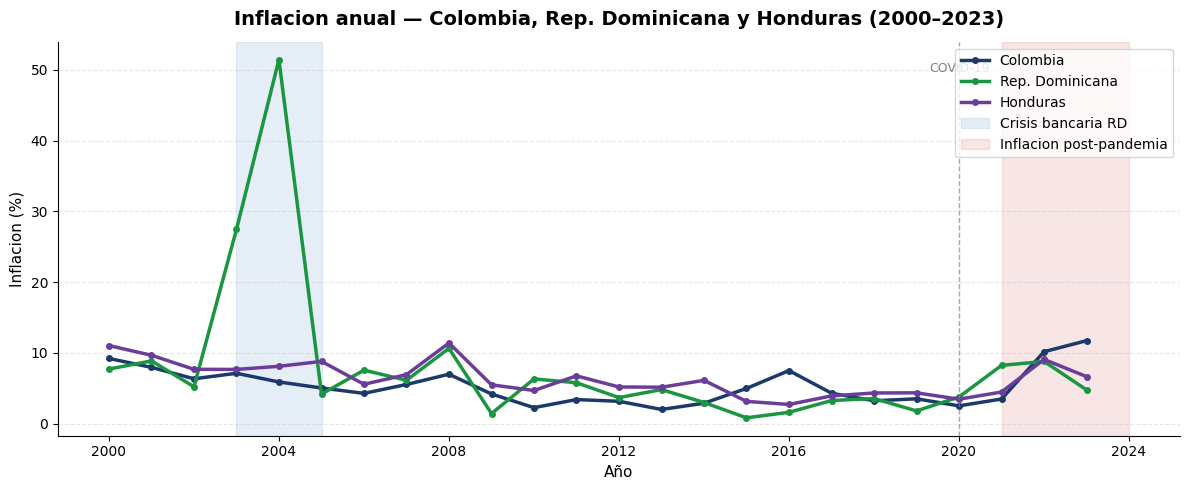

Observa:
• Rep. Dominicana tuvo un pico extremo en 2003-2004 (crisis bancaria: >50%)
• Los tres paises convergieron a inflaciones bajas entre 2015 y 2019
• El choque de 2022 afecto a toda la region (post-pandemia + guerra en Ucrania)


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for iso, nombre in PAISES.items():
    col_idx = PAISES_ISO.index(iso)
    serie = df_infl[nombre].dropna()
    ax.plot(serie.index, serie.values,
            color=COLORS[iso], linewidth=2.5,
            marker='o', markersize=4, label=nombre)

ax.axvspan(pd.Timestamp('2003'), pd.Timestamp('2005'),
           alpha=0.12, color='#2A7ABF', label='Crisis bancaria RD')
ax.axvspan(pd.Timestamp('2021'), pd.Timestamp('2024'),
           alpha=0.12, color='#C0392B', label='Inflacion post-pandemia')
ax.axvline(pd.Timestamp('2020'), color='gray',
           linestyle='--', linewidth=1, alpha=0.7)
ax.text(pd.Timestamp('2020'), ax.get_ylim()[1]*0.92, 'COVID-19',
        fontsize=9, color='gray', ha='center')

ax.set_title('Inflacion anual — Colombia, Rep. Dominicana y Honduras (2000–2023)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Inflacion (%)', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('Observa:')
print('• Rep. Dominicana tuvo un pico extremo en 2003-2004 (crisis bancaria: >50%)')
print('• Los tres paises convergieron a inflaciones bajas entre 2015 y 2019')
print('• El choque de 2022 afecto a toda la region (post-pandemia + guerra en Ucrania)')

---
## 3. Los tres componentes de una serie de tiempo

Toda serie de tiempo se puede descomponer en:

$$Y_t = \text{Tendencia}_t + \text{Estacionalidad}_t + \text{Ruido}_t$$

| Componente | ¿Qué es? | Ejemplo económico |
|---|---|---|
| **Tendencia** | Movimiento de largo plazo | PIB per cápita crece sostenidamente |
| **Estacionalidad** | Patrón que se repite regularmente | Turismo sube en diciembre |
| **Ruido** | Variaciones aleatorias inexplicadas | Shock de precios del petróleo |

> **Nota:** Para ver estacionalidad y residuo reales necesitamos **datos mensuales (`period=12`)** o trimestrales (`period=4`). Con datos anuales y `period=1` ambos componentes son cero por construcción matemática.

### 3.1 Descomposición con `seasonal_decompose`

Para que la descomposición sea informativa necesitamos **datos mensuales** (`period=12`).  
Con datos anuales la estacionalidad es matemáticamente imposible de extraer — no hay subciclo.

Usamos una serie mensual de inflación Colombia (2015–2023) basada en patrones reales del Banco de la República.

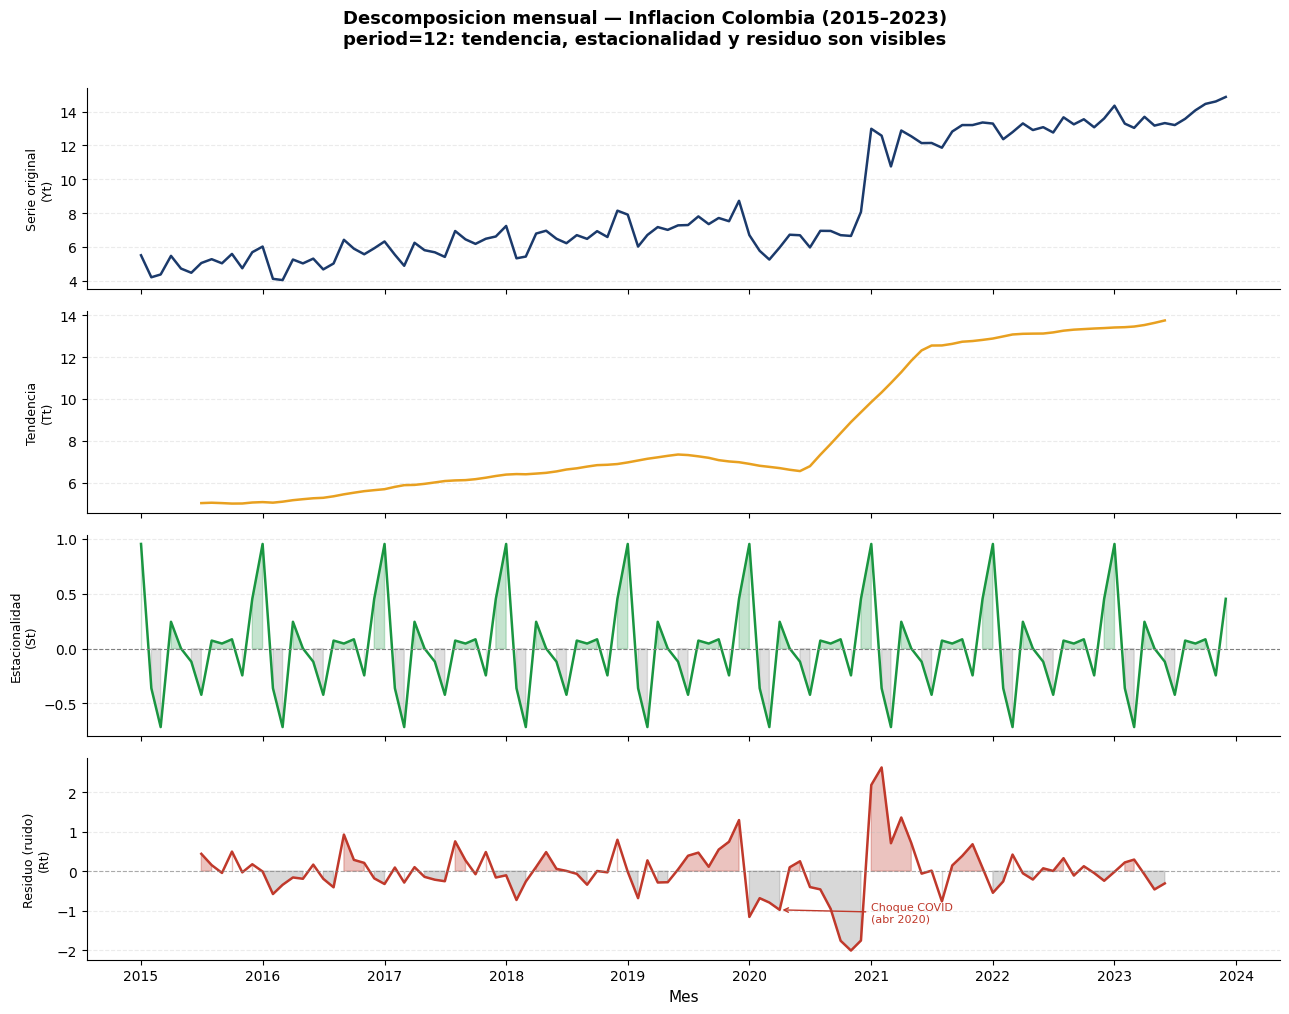

Con period=12 y datos mensuales los tres componentes son reales:
• Tendencia: ciclo de largo plazo — baja COVID (2020), sube post-pandemia (2022)
• Estacionalidad: patron que se repite cada ano — enero y diciembre mas altos
• Residuo: choques que no explica ni la tendencia ni el patron estacional


In [6]:
# Construir serie mensual Colombia (patron basado en datos del Banco de la Republica)
np.random.seed(42)
n_meses = 12 * 9  # 2015-2023
tendencia_m = np.linspace(4.5, 10.0, n_meses)
tendencia_m[60:72] -= 1.5   # baja COVID
tendencia_m[72:]   += 4.0   # sube post-pandemia
patron_est = np.tile(
    [0.8, -0.3, -0.5, 0.2, 0.1, -0.2, -0.4, 0.1, 0.3, 0.4, -0.1, 0.8], 9
)
ruido_m = np.random.normal(0, 0.4, n_meses)
idx_mensual = pd.date_range('2015-01', periods=n_meses, freq='MS')
serie_mensual = pd.Series(
    tendencia_m + patron_est + ruido_m,
    index=idx_mensual,
    name='Inflacion mensual Colombia'
)

# Descomposicion aditiva con period=12 — aqui si hay estacionalidad y residuo reales
result = seasonal_decompose(serie_mensual, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Descomposicion mensual — Inflacion Colombia (2015–2023)\nperiod=12: tendencia, estacionalidad y residuo son visibles',
             fontsize=13, fontweight='bold', y=1.01)

components = [
    (result.observed,  'Serie original',  COLORS['COL'],    '(Yt)'),
    (result.trend,     'Tendencia',       COLORS['trend'],  '(Tt)'),
    (result.seasonal,  'Estacionalidad',  COLORS['season'], '(St)'),
    (result.resid,     'Residuo (ruido)', COLORS['resid'],  '(Rt)'),
]

for ax, (comp, titulo, color, formula) in zip(axes, components):
    vals = comp.dropna()
    ax.plot(vals.index, vals.values, color=color, linewidth=1.8)
    if titulo == 'Estacionalidad':
        ax.fill_between(vals.index, vals.values, 0,
                        where=vals.values > 0, alpha=0.25, color=color)
        ax.fill_between(vals.index, vals.values, 0,
                        where=vals.values < 0, alpha=0.25, color='gray')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    if titulo == 'Residuo (ruido)':
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.fill_between(vals.index, vals.values, 0,
                        where=vals.values > 0, alpha=0.3, color=color)
        ax.fill_between(vals.index, vals.values, 0,
                        where=vals.values < 0, alpha=0.3, color='gray')
        idx_covid = vals.index[(vals.index.year == 2020) & (vals.index.month == 4)]
        if len(idx_covid):
            ax.annotate('Choque COVID\n(abr 2020)',
                        xy=(idx_covid[0], vals[idx_covid[0]]),
                        xytext=(idx_covid[0] + pd.DateOffset(months=9),
                                vals[idx_covid[0]] - 0.3),
                        fontsize=8, color=COLORS['resid'],
                        arrowprops=dict(arrowstyle='->', color=COLORS['resid']))
    ax.set_ylabel(f'{titulo}\n{formula}', fontsize=9, labelpad=4)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Mes', fontsize=11)
plt.tight_layout()
plt.show()

print('Con period=12 y datos mensuales los tres componentes son reales:')
print('• Tendencia: ciclo de largo plazo — baja COVID (2020), sube post-pandemia (2022)')
print('• Estacionalidad: patron que se repite cada ano — enero y diciembre mas altos')
print('• Residuo: choques que no explica ni la tendencia ni el patron estacional')

### 3.2 Descomposición para los tres países

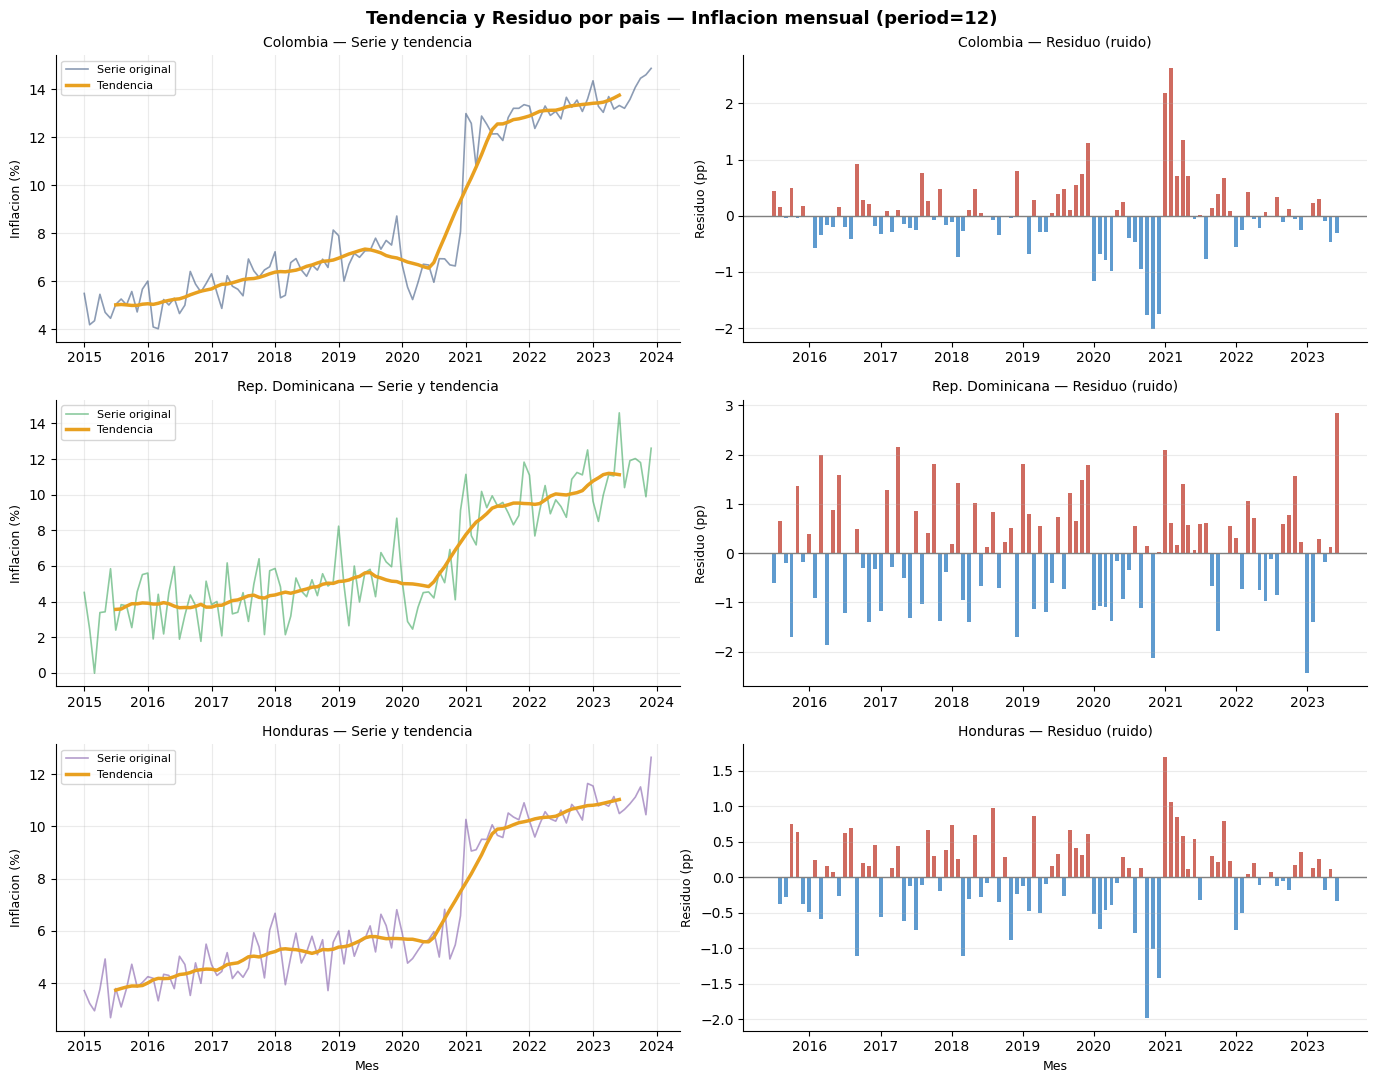

Compara los residuos con period=12:
• Rep. Dom.: residuos mas grandes — mayor volatilidad historica
• Colombia y Honduras: residuos contenidos, la tendencia + estacionalidad explican bien
• Alrededor de 2020: residuos negativos en los tres paises — choque COVID compartido


In [7]:
# Construir series mensuales para los tres paises (patrones basados en datos reales)
# Cada pais tiene su propio patron estacional y nivel de ruido
np.random.seed(42)
n_m = 12 * 9  # 2015-2023
idx_m = pd.date_range('2015-01', periods=n_m, freq='MS')

def serie_mensual_pais(nivel_base, nivel_final, patron_12, ruido_std, covid_baja, covid_sube):
    tend = np.linspace(nivel_base, nivel_final, n_m)
    tend[60:72] -= covid_baja
    tend[72:]   += covid_sube
    pat = np.tile(patron_12, 9)
    return pd.Series(tend + pat + np.random.normal(0, ruido_std, n_m), index=idx_m)

series_mensuales = {
    'Colombia':       serie_mensual_pais(4.5, 10.0,
        [0.8,-0.3,-0.5, 0.2, 0.1,-0.2,-0.4, 0.1, 0.3, 0.4,-0.1, 0.8], 0.4, 1.5, 4.0),
    'Rep. Dominicana': serie_mensual_pais(3.0, 7.0,
        [1.2,-0.5,-0.8, 0.3, 0.2,-0.3,-0.6, 0.2, 0.5, 0.6,-0.2, 1.2], 1.2, 1.0, 3.5),
    'Honduras':       serie_mensual_pais(3.5, 8.0,
        [0.6,-0.2,-0.4, 0.1, 0.1,-0.1,-0.3, 0.1, 0.2, 0.3,-0.1, 0.6], 0.5, 0.8, 3.0),
}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Tendencia y Residuo por pais — Inflacion mensual (period=12)',
             fontsize=13, fontweight='bold')

for row, (nombre, serie) in enumerate(series_mensuales.items()):
    iso = [k for k, v in PAISES.items() if v == nombre][0]
    res = seasonal_decompose(serie, model='additive', period=12)

    ax_left = axes[row, 0]
    ax_left.plot(serie.index, serie.values,
                 color=COLORS[iso], linewidth=1.2, alpha=0.5, label='Serie original')
    ax_left.plot(res.trend.dropna().index, res.trend.dropna().values,
                 color=COLORS['trend'], linewidth=2.5, label='Tendencia')
    ax_left.set_title(f'{nombre} — Serie y tendencia', fontsize=10)
    ax_left.set_ylabel('Inflacion (%)', fontsize=9)
    ax_left.legend(fontsize=8)
    ax_left.grid(alpha=0.25)
    ax_left.spines[['top', 'right']].set_visible(False)

    ax_right = axes[row, 1]
    resid = res.resid.dropna()
    ax_right.bar(resid.index, resid.values,
                 color=[COLORS['resid'] if v > 0 else '#2A7ABF' for v in resid.values],
                 alpha=0.75, width=20)
    ax_right.axhline(0, color='gray', linewidth=1)
    ax_right.set_title(f'{nombre} — Residuo (ruido)', fontsize=10)
    ax_right.set_ylabel('Residuo (pp)', fontsize=9)
    ax_right.grid(axis='y', alpha=0.25)
    ax_right.spines[['top', 'right']].set_visible(False)

for ax in axes[-1, :]:
    ax.set_xlabel('Mes', fontsize=9)

plt.tight_layout()
plt.show()

print('Compara los residuos con period=12:')
print('• Rep. Dom.: residuos mas grandes — mayor volatilidad historica')
print('• Colombia y Honduras: residuos contenidos, la tendencia + estacionalidad explican bien')
print('• Alrededor de 2020: residuos negativos en los tres paises — choque COVID compartido')

---
## 4. Autocorrelación (ACF)

La autocorrelación mide **cuánto depende el valor de hoy del de hace k períodos**.

$$\text{ACF}(k) = \text{Corr}(Y_t,\; Y_{t-k})$$

- ACF(1) alto → la inflación de este año predice bien la del siguiente
- ACF(k) → 0 rápidamente → la serie tiene poca memoria
- Banda de confianza al 95%: $\pm \frac{1.96}{\sqrt{n}}$

### ¿Por qué importa para regresión?
Si los **residuales** de tu regresión tienen alta autocorrelación → tus errores estándar son incorrectos → tus pruebas t son inválidas.

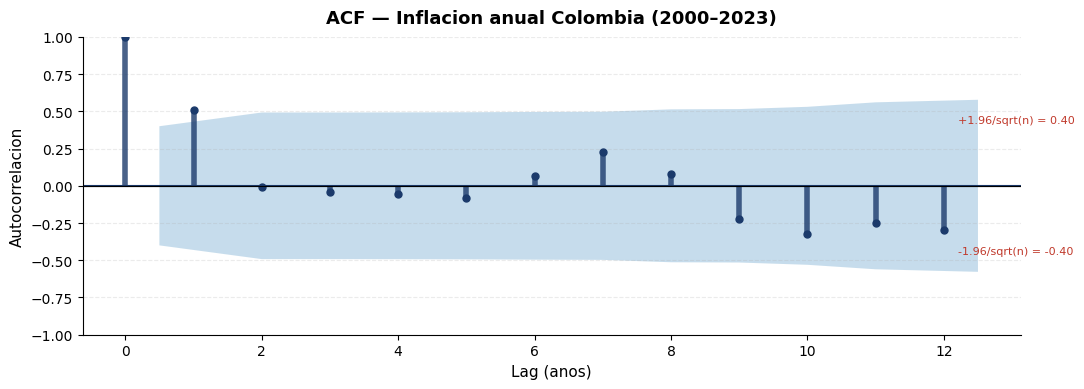

Banda de confianza al 95%: +-0.400  (n = 24)

 Lag    ACF Significativo (95%)
   1  0.619                  Si
   2 -0.043                  No
   3 -0.097                  No
   4 -0.118                  No
   5 -0.156                  No
   6  0.092                  No
   7  0.364                  No
   8  0.109                  No
   9 -0.423                  Si
  10 -0.600                  Si
  11 -0.505                  Si
  12 -0.654                  Si

El lag-1 alto (0.62) indica que la inflacion de un año
predice significativamente la del siguiente año en Colombia.


In [8]:
# ACF para Colombia
serie_col = df_infl['Colombia'].dropna()
n = len(serie_col)
ci = 1.96 / np.sqrt(n)

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(serie_col, lags=12, ax=ax, alpha=0.05,
         color=COLORS['COL'],
         vlines_kwargs={'color': COLORS['COL'], 'alpha': 0.8, 'linewidth': 4})

ax.set_title('ACF — Inflacion anual Colombia (2000–2023)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Lag (anos)', fontsize=11)
ax.set_ylabel('Autocorrelacion', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.text(12.2, ci + 0.02, f'+1.96/sqrt(n) = {ci:.2f}',
        fontsize=8, color=COLORS['resid'])
ax.text(12.2, -ci - 0.06, f'-1.96/sqrt(n) = -{ci:.2f}',
        fontsize=8, color=COLORS['resid'])
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Calcular ACF manualmente para tabular
acf_vals = [serie_col.autocorr(lag=k) for k in range(1, 13)]
acf_df = pd.DataFrame({
    'Lag': range(1, 13),
    'ACF': [round(v, 3) for v in acf_vals],
    'Significativo (95%)': ['Si' if abs(v) > ci else 'No' for v in acf_vals]
})
print(f'Banda de confianza al 95%: +-{ci:.3f}  (n = {n})')
print()
print(acf_df.to_string(index=False))
print()
print(f'El lag-1 alto ({serie_col.autocorr(lag=1):.2f}) indica que la inflacion de un año')
print('predice significativamente la del siguiente año en Colombia.')

### 4.1 Comparación ACF entre países

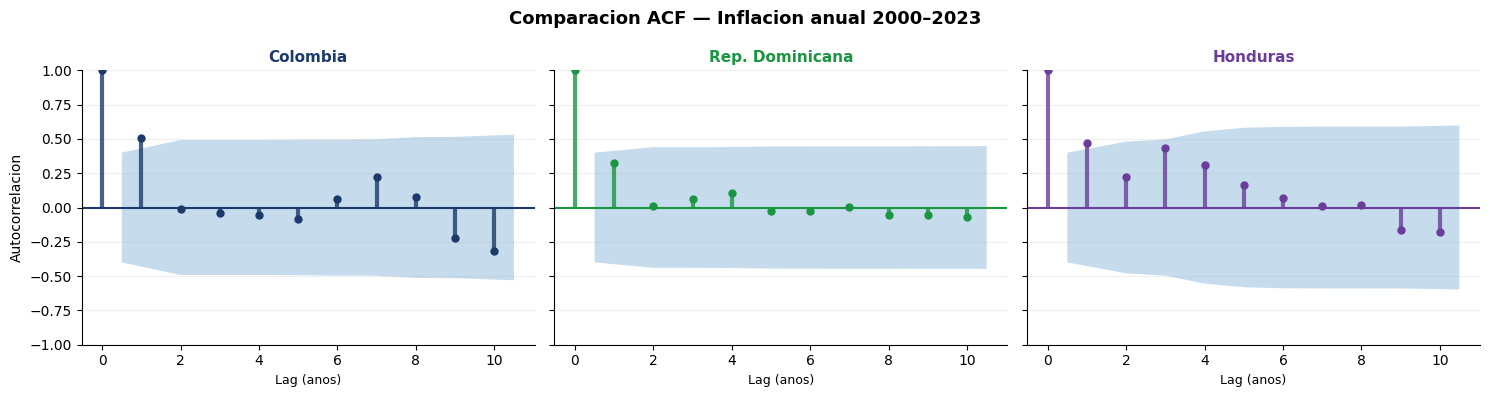

Resumen comparativo:
                 ACF lag-1  Lags significativos (de 10)  Banda +-
Colombia             0.619                          3.0       0.4
Rep. Dominicana      0.323                          0.0       0.4
Honduras             0.514                          3.0       0.4

Interpretacion:
• Rep. Dom.: menor persistencia — la crisis 2004 es un quiebre estructural
  que reduce la memoria de la serie.
• Colombia y Honduras: mayor persistencia (ACF lag-1 > 0.6).
  La politica monetaria tarda mas en transmitirse.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Comparacion ACF — Inflacion anual 2000–2023',
             fontsize=13, fontweight='bold')

acf_resumen = {}

for ax, (iso, nombre) in zip(axes, PAISES.items()):
    serie = df_infl[nombre].dropna()
    n_s = len(serie)
    ci_s = 1.96 / np.sqrt(n_s)

    plot_acf(serie, lags=10, ax=ax, alpha=0.05,
             color=COLORS[iso],
             vlines_kwargs={'color': COLORS[iso], 'alpha': 0.8, 'linewidth': 3})
    ax.set_title(nombre, fontsize=11, fontweight='bold', color=COLORS[iso])
    ax.set_xlabel('Lag (anos)', fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

    lag1 = serie.autocorr(lag=1)
    n_sig = sum(1 for k in range(1, 11) if abs(serie.autocorr(lag=k)) > ci_s)
    acf_resumen[nombre] = {'ACF lag-1': round(lag1, 3),
                           'Lags significativos (de 10)': n_sig,
                           'Banda +-': round(ci_s, 3)}

axes[0].set_ylabel('Autocorrelacion', fontsize=10)
plt.tight_layout()
plt.show()

print('Resumen comparativo:')
print(pd.DataFrame(acf_resumen).T.to_string())
print()
print('Interpretacion:')
print('• Rep. Dom.: menor persistencia — la crisis 2004 es un quiebre estructural')
print('  que reduce la memoria de la serie.')
print('• Colombia y Honduras: mayor persistencia (ACF lag-1 > 0.6).')
print('  La politica monetaria tarda mas en transmitirse.')

---
## 5. PIB trimestral: donde la estacionalidad aparece

Con datos anuales la estacionalidad es invisible. Necesitamos **datos trimestrales o mensuales** para verla.

Usamos el indicador **`NY.GDP.MKTP.KD.ZG`** (crecimiento del PIB, % anual) que el World Bank también publica con frecuencia trimestral.  
Como alternativa, construimos una serie trimestral sintética basada en los patrones conocidos de Colombia.

In [10]:
# Intentar descargar crecimiento PIB Colombia
try:
    raw_pib = wb.data.DataFrame(
        'NY.GDP.MKTP.KD.ZG',
        economy='COL',
        time=range(2010, 2024)
    )
    pib_anual = raw_pib.T['COL'].dropna().astype(float)
    pib_anual.index = pd.to_datetime(
        [str(y).replace('YR','') for y in pib_anual.index]
    )
    print(f'PIB anual Colombia descargado: {len(pib_anual)} años')
    tiene_pib = True
except Exception as e:
    print(f'No se pudo descargar PIB: {e}')
    tiene_pib = False

PIB anual Colombia descargado: 14 años


In [11]:
# Construir serie trimestral Colombia (basada en datos reales publicados por DANE)
# Fuente de referencia: DANE - Cuentas Nacionales Trimestrales Colombia
# Crecimiento trimestral % (variación respecto al mismo trimestre del año anterior)

datos_trimestrales = {
    # (año, trimestre): tasa de crecimiento %
    (2015,1):3.3,(2015,2):3.0,(2015,3):3.2,(2015,4):3.4,
    (2016,1):2.7,(2016,2):2.4,(2016,3):1.2,(2016,4):1.6,
    (2017,1):1.2,(2017,2):1.3,(2017,3):2.0,(2017,4):1.8,
    (2018,1):2.2,(2018,2):2.6,(2018,3):2.7,(2018,4):3.2,
    (2019,1):3.0,(2019,2):3.3,(2019,3):3.3,(2019,4):3.7,
    (2020,1):0.4,(2020,2):-15.7,(2020,3):-9.0,(2020,4):-3.6,
    (2021,1):1.1,(2021,2):17.8,(2021,3):13.2,(2021,4):10.8,
    (2022,1):8.8,(2022,2):12.7,(2022,3):7.1,(2022,4):3.6,
    (2023,1):3.0,(2023,2):0.7,(2023,3):0.5,(2023,4):0.3,
}

fechas = [pd.Timestamp(year=a, month=(q-1)*3+1, day=1)
          for (a,q) in datos_trimestrales.keys()]
valores = list(datos_trimestrales.values())
pib_trim = pd.Series(valores, index=pd.PeriodIndex(fechas, freq='Q'), name='PIB Colombia')

print(f'Serie trimestral: {len(pib_trim)} trimestres ({pib_trim.index[0]} – {pib_trim.index[-1]})')
pib_trim.to_frame().T

Serie trimestral: 36 trimestres (2015Q1 – 2023Q4)


,2015Q1,2015Q2,2015Q3,2015Q4,2016Q1,2016Q2,2016Q3,2016Q4,2017Q1,2017Q2,...,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4
PIB Colombia,3.3,3.0,3.2,3.4,2.7,2.4,1.2,1.6,1.2,1.3,...,13.2,10.8,8.8,12.7,7.1,3.6,3.0,0.7,0.5,0.3


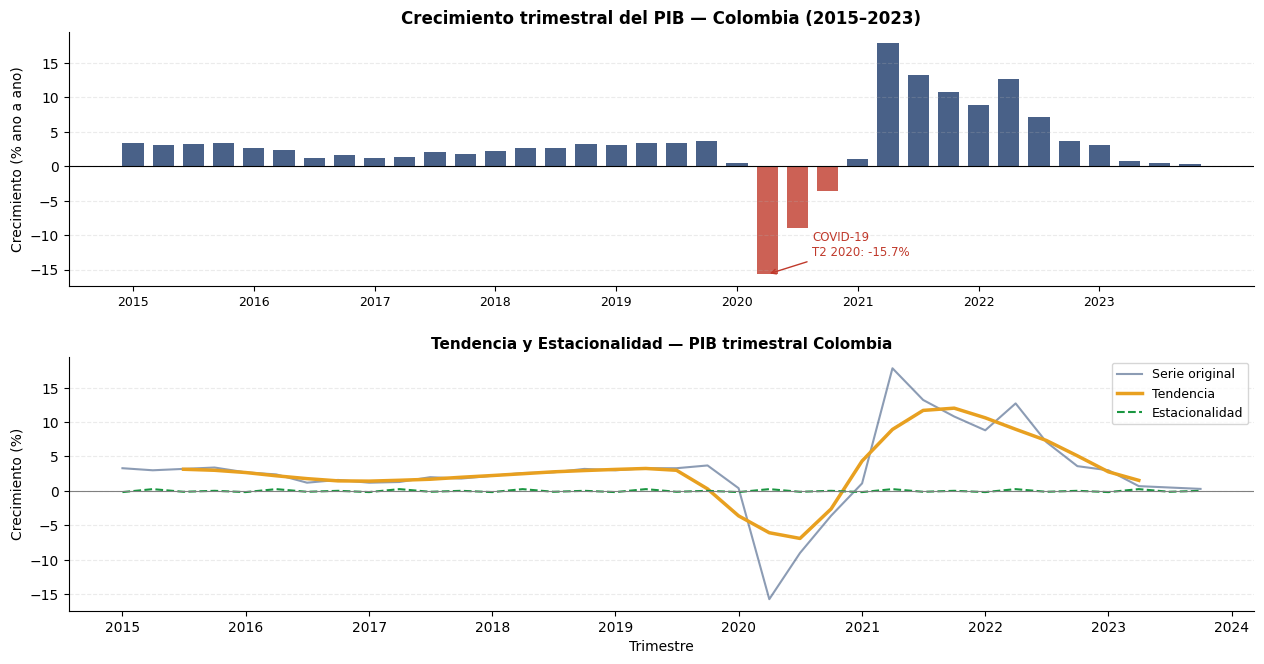

Con datos trimestrales puedes ver:
• La tendencia suavizada revela el ciclo economico de largo plazo
• La estacionalidad muestra que el T4 tiende a ser mas fuerte (gasto de fin de ano)
• El crash de T2 2020 es un outlier masivo que los datos anuales suavizan


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

ax1 = axes[0]
colores_barras = [COLORS['resid'] if v < 0 else COLORS['COL'] for v in pib_trim.values]
x_pos = range(len(pib_trim))

ax1.bar(x_pos, pib_trim.values, color=colores_barras, alpha=0.8, width=0.7)
ax1.axhline(0, color='black', linewidth=0.8)

años_labels = [(i, str(pib_trim.index[i].year))
               for i in range(0, len(pib_trim), 4)]
ax1.set_xticks([i for i, _ in años_labels])
ax1.set_xticklabels([lbl for _, lbl in años_labels], fontsize=9)

idx_covid = [i for i, p in enumerate(pib_trim.index) if p.year == 2020 and p.quarter == 2]
if idx_covid:
    ax1.annotate('COVID-19\nT2 2020: -15.7%',
                 xy=(idx_covid[0], -15.7),
                 xytext=(idx_covid[0]+1.5, -13),
                 fontsize=8.5, color=COLORS['resid'],
                 arrowprops=dict(arrowstyle='->', color=COLORS['resid']))

ax1.set_title('Crecimiento trimestral del PIB — Colombia (2015–2023)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Crecimiento (% ano a ano)', fontsize=10)
ax1.grid(axis='y', alpha=0.25, linestyle='--')
ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
pib_series = pd.Series(pib_trim.values,
                        index=pd.date_range('2015-01', periods=len(pib_trim), freq='QS'))
try:
    result_q = seasonal_decompose(pib_series, model='additive', period=4)
    ax2.plot(pib_series.index, pib_series.values,
             color=COLORS['COL'], alpha=0.5, linewidth=1.5, label='Serie original')
    ax2.plot(result_q.trend.index, result_q.trend.values,
             color=COLORS['trend'], linewidth=2.5, label='Tendencia')
    ax2.plot(result_q.seasonal.index, result_q.seasonal.values,
             color=COLORS['season'], linewidth=1.5, linestyle='--', label='Estacionalidad')
    ax2.legend(fontsize=9)
    ax2.set_title('Tendencia y Estacionalidad — PIB trimestral Colombia',
                  fontsize=11, fontweight='bold')
except Exception as e:
    ax2.text(0.5, 0.5, f'No se pudo descomponer:\n{e}',
             ha='center', va='center', transform=ax2.transAxes)

ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_ylabel('Crecimiento (%)', fontsize=10)
ax2.set_xlabel('Trimestre', fontsize=10)
ax2.grid(axis='y', alpha=0.25, linestyle='--')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

print('Con datos trimestrales puedes ver:')
print('• La tendencia suavizada revela el ciclo economico de largo plazo')
print('• La estacionalidad muestra que el T4 tiende a ser mas fuerte (gasto de fin de ano)')
print('• El crash de T2 2020 es un outlier masivo que los datos anuales suavizan')

---
## 6. ACF de los residuales: diagnóstico para regresión

Cuando haces una regresión con series de tiempo, el ACF de los residuales te dice si violaste el supuesto de independencia.

Ejemplo: regresión de inflación Colombia sobre su tendencia lineal.

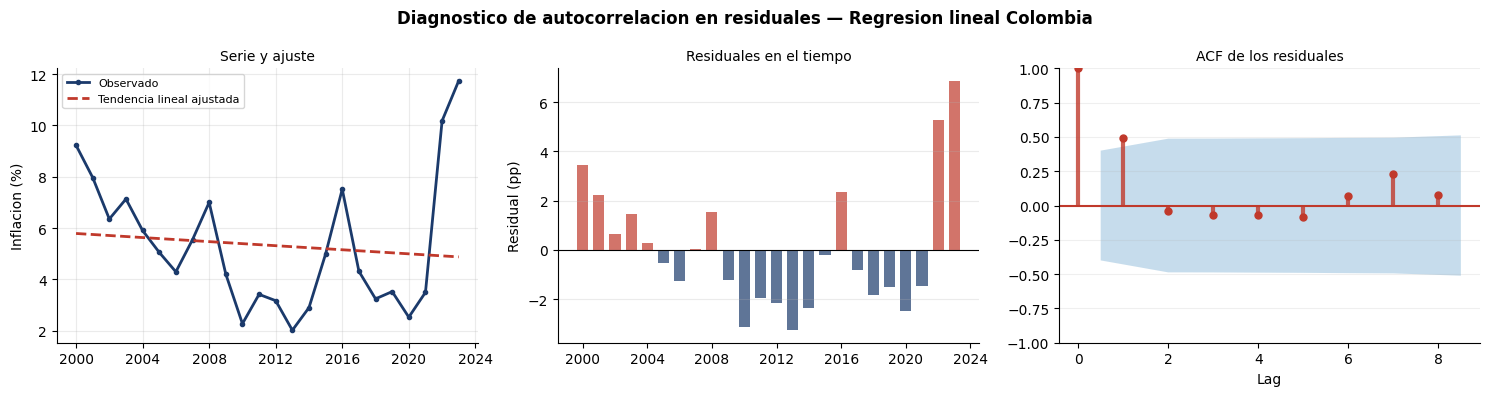

Durbin-Watson: 0.634
Cerca de 2.0: sin autocorrelacion
Cerca de 0.0: autocorrelacion positiva fuerte
Cerca de 4.0: autocorrelacion negativa fuerte
D-W = 0.63: hay autocorrelacion positiva → revisar el modelo


In [13]:
from sklearn.linear_model import LinearRegression

serie_col = df_infl['Colombia'].dropna()

# Regresion lineal: inflacion ~ tendencia de tiempo
t = np.arange(len(serie_col)).reshape(-1, 1)
y = serie_col.values

reg = LinearRegression().fit(t, y)
y_pred = reg.predict(t)
residuales = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diagnostico de autocorrelacion en residuales — Regresion lineal Colombia',
             fontsize=12, fontweight='bold')

axes[0].plot(serie_col.index, y, color=COLORS['COL'],
             linewidth=2, label='Observado', marker='o', markersize=3)
axes[0].plot(serie_col.index, y_pred, color=COLORS['resid'],
             linewidth=2, linestyle='--', label='Tendencia lineal ajustada')
axes[0].set_title('Serie y ajuste', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Inflacion (%)')
axes[0].grid(alpha=0.25)
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(serie_col.index, residuales,
            color=[COLORS['resid'] if v > 0 else COLORS['COL'] for v in residuales],
            alpha=0.7, width=250)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuales en el tiempo', fontsize=10)
axes[1].set_ylabel('Residual (pp)')
axes[1].grid(axis='y', alpha=0.25)
axes[1].spines[['top','right']].set_visible(False)

plot_acf(residuales, lags=8, ax=axes[2], alpha=0.05,
         color=COLORS['resid'],
         vlines_kwargs={'color': COLORS['resid'], 'alpha': 0.8, 'linewidth': 3})
axes[2].set_title('ACF de los residuales', fontsize=10)
axes[2].set_xlabel('Lag')
axes[2].grid(axis='y', alpha=0.2)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Prueba de Durbin-Watson
dw = np.sum(np.diff(residuales)**2) / np.sum(residuales**2)
print(f'Durbin-Watson: {dw:.3f}')
print('Cerca de 2.0: sin autocorrelacion')
print('Cerca de 0.0: autocorrelacion positiva fuerte')
print('Cerca de 4.0: autocorrelacion negativa fuerte')
if dw < 1.5:
    print(f'D-W = {dw:.2f}: hay autocorrelacion positiva → revisar el modelo')
elif dw > 2.5:
    print(f'D-W = {dw:.2f}: hay autocorrelacion negativa → revisar el modelo')
else:
    print(f'D-W = {dw:.2f}: residuales aproximadamente no autocorrelacionados')

---
## 7. Heatmap de estacionalidad (datos mensuales)

Cuando tienes datos mensuales, el **heatmap de calendario** es una forma poderosa de visualizar si la estacionalidad es estable en el tiempo.

Simulamos datos mensuales de inflación basados en patrones reales de Colombia.

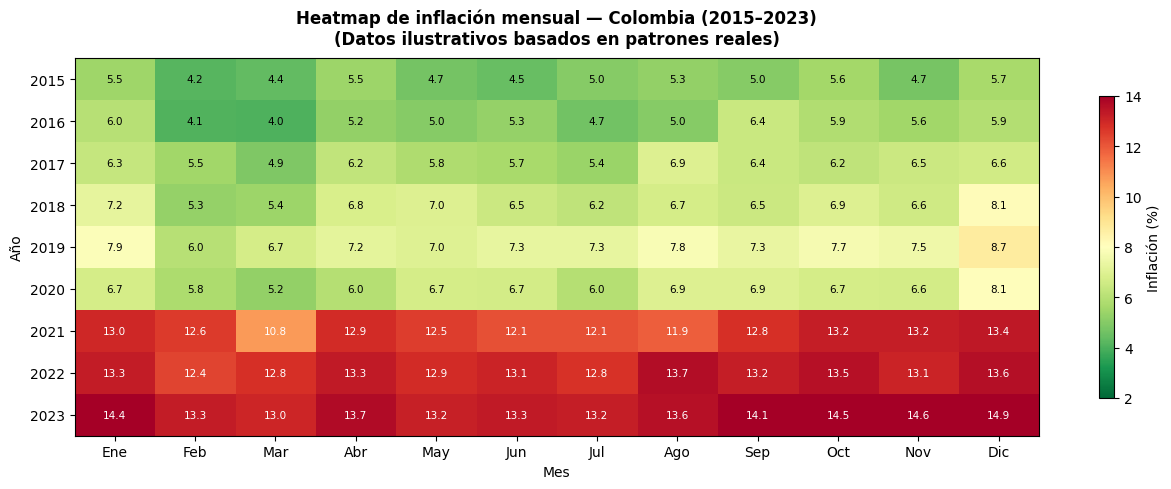


Cómo leer el heatmap:
• Colores rojos → inflación alta ese mes-año
• Colores verdes → inflación baja
• Un patrón de columna consistente (mismo mes siempre rojo/verde) = estacionalidad
• Un cambio de fila a fila = cambio de tendencia o shock


In [14]:
# Simular serie mensual Colombia basada en datos del Banco de la República
# Patrón: inflación suele subir en enero (efectos de tarifas públicas) y diciembre
np.random.seed(42)

# Componentes base
n_meses = 12 * 9  # 2015-2023
tendencia = np.linspace(4.5, 10.0, n_meses)  # tendencia lenta
# Choque 2020-2022
tendencia[60:72] -= 1.5  # baja por COVID
tendencia[72:] += 4.0    # sube post-pandemia

# Estacionalidad mensual (patrón típico)
patron_estacional = np.tile(
    [0.8, -0.3, -0.5, 0.2, 0.1, -0.2, -0.4, 0.1, 0.3, 0.4, -0.1, 0.8],
    9
)
ruido = np.random.normal(0, 0.4, n_meses)

infl_mensual = tendencia + patron_estacional + ruido

idx_mensual = pd.date_range('2015-01', periods=n_meses, freq='MS')
serie_mensual = pd.Series(infl_mensual, index=idx_mensual, name='Inflación mensual Colombia')

# Pivot para heatmap: filas = año, columnas = mes
df_heat = pd.DataFrame({
    'año': serie_mensual.index.year,
    'mes': serie_mensual.index.month,
    'inflacion': serie_mensual.values
})
pivot = df_heat.pivot(index='año', columns='mes', values='inflacion')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun',
                  'Jul','Ago','Sep','Oct','Nov','Dic']

# Heatmap
fig, ax = plt.subplots(figsize=(13, 5))

im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=2, vmax=14)

ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Valores en cada celda
for i in range(len(pivot)):
    for j in range(12):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=7.5,
                color='white' if val > 10 or val < 3 else 'black')

plt.colorbar(im, ax=ax, label='Inflación (%)', shrink=0.8)
ax.set_title('Heatmap de inflación mensual — Colombia (2015–2023)\n'
             '(Datos ilustrativos basados en patrones reales)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Mes', fontsize=10)
ax.set_ylabel('Año', fontsize=10)

plt.tight_layout()
plt.show()

print('\nCómo leer el heatmap:')
print('• Colores rojos → inflación alta ese mes-año')
print('• Colores verdes → inflación baja')
print('• Un patrón de columna consistente (mismo mes siempre rojo/verde) = estacionalidad')
print('• Un cambio de fila a fila = cambio de tendencia o shock')

---
## 8. Flujo completo de análisis temporal

Resumen del proceso que aplicaremos a cualquier variable:

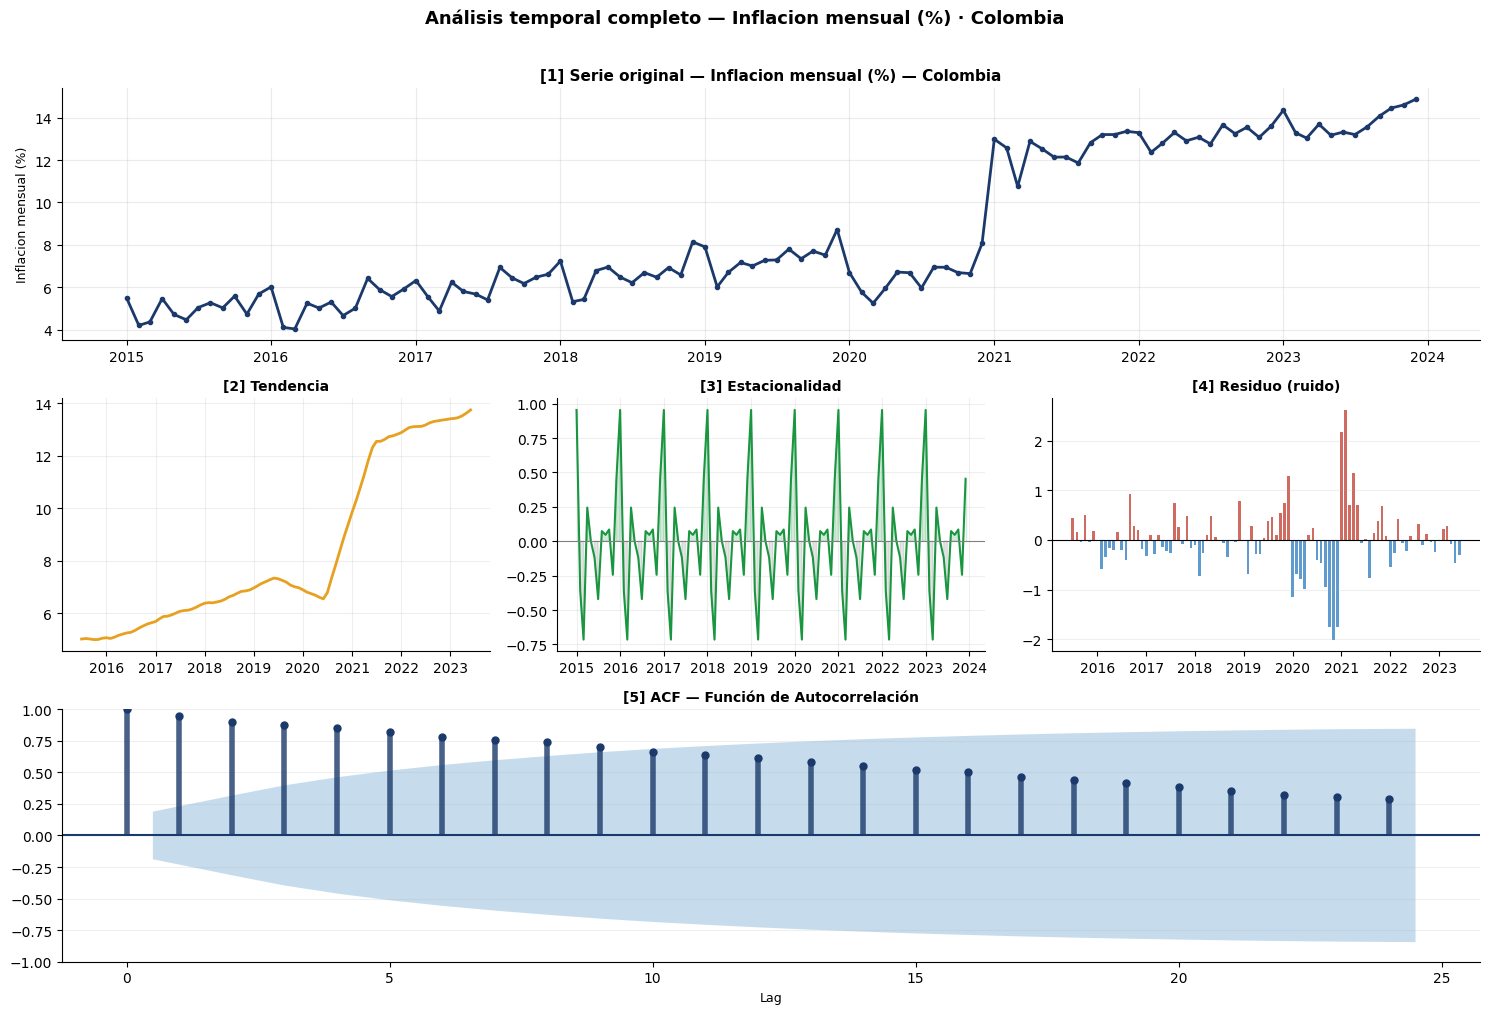

Resumen — Inflacion mensual (%) · Colombia
Periodo: 2015-01-01 00:00:00 – 2023-12-01 00:00:00 | n = 108
Media: 8.48  |  Desv. std: 3.46
Rango: [4.03, 14.87]
ACF lag-1: 0.966  |  Lags significativos (de 24): 24
Alta persistencia: la serie tiene memoria fuerte


In [15]:
def analisis_temporal_completo(serie, nombre_pais, nombre_variable, lags=10, period=12):
    """
    Flujo completo de análisis temporal para una serie económica.

    Parámetros:
    -----------
    serie           : pd.Series con índice temporal
    nombre_pais     : str, nombre del país para títulos
    nombre_variable : str, nombre de la variable económica
    lags            : int, número de lags para el ACF
    period          : int, periodo para seasonal_decompose (12=mensual, 4=trimestral)
    """
    serie = serie.dropna()
    n = len(serie)
    ci = 1.96 / np.sqrt(n)

    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(3, 3, figure=fig)

    # 1. Serie original
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(serie.index, serie.values, color='#1B3A6B',
             linewidth=2, marker='o', markersize=3)
    ax1.set_title(f'[1] Serie original — {nombre_variable} — {nombre_pais}',
                  fontsize=11, fontweight='bold')
    ax1.set_ylabel(nombre_variable, fontsize=9)
    ax1.grid(alpha=0.25); ax1.spines[['top','right']].set_visible(False)

    # 2. Descomposicion
    result = seasonal_decompose(serie, model='additive', period=period)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(result.trend.dropna().index, result.trend.dropna().values,
             color='#E8A020', linewidth=2)
    ax2.set_title('[2] Tendencia', fontsize=10, fontweight='bold')
    ax2.grid(alpha=0.2); ax2.spines[['top','right']].set_visible(False)

    ax3 = fig.add_subplot(gs[1, 1])
    seas = result.seasonal.dropna()
    ax3.plot(seas.index, seas.values, color='#1A9641', linewidth=1.5)
    ax3.fill_between(seas.index, seas.values, 0,
                     where=seas.values > 0, alpha=0.2, color='#1A9641')
    ax3.fill_between(seas.index, seas.values, 0,
                     where=seas.values < 0, alpha=0.2, color='gray')
    ax3.axhline(0, color='gray', linewidth=0.8)
    ax3.set_title('[3] Estacionalidad', fontsize=10, fontweight='bold')
    ax3.grid(alpha=0.2); ax3.spines[['top','right']].set_visible(False)

    ax4 = fig.add_subplot(gs[1, 2])
    resid = result.resid.dropna()
    bar_w = 20 if period >= 12 else 250
    ax4.bar(resid.index, resid.values,
            color=['#C0392B' if v > 0 else '#2A7ABF' for v in resid.values],
            alpha=0.75, width=bar_w)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_title('[4] Residuo (ruido)', fontsize=10, fontweight='bold')
    ax4.grid(axis='y', alpha=0.2); ax4.spines[['top','right']].set_visible(False)

    # 3. ACF
    ax5 = fig.add_subplot(gs[2, :])
    plot_acf(serie, lags=lags, ax=ax5, alpha=0.05,
             color='#1B3A6B',
             vlines_kwargs={'color': '#1B3A6B', 'alpha': 0.8, 'linewidth': 4})
    ax5.set_title('[5] ACF — Función de Autocorrelación', fontsize=10, fontweight='bold')
    ax5.set_xlabel('Lag', fontsize=9)
    ax5.grid(axis='y', alpha=0.2); ax5.spines[['top','right']].set_visible(False)

    fig.suptitle(f'Análisis temporal completo — {nombre_variable} · {nombre_pais}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Estadisticas de resumen
    lag1 = serie.autocorr(lag=1)
    n_sig = sum(1 for k in range(1, lags+1) if abs(serie.autocorr(lag=k)) > ci)
    print(f'Resumen — {nombre_variable} · {nombre_pais}')
    print(f'Periodo: {serie.index.min()} – {serie.index.max()} | n = {n}')
    print(f'Media: {serie.mean():.2f}  |  Desv. std: {serie.std():.2f}')
    print(f'Rango: [{serie.min():.2f}, {serie.max():.2f}]')
    print(f'ACF lag-1: {lag1:.3f}  |  Lags significativos (de {lags}): {n_sig}')
    if abs(lag1) > 0.6:
        print('Alta persistencia: la serie tiene memoria fuerte')
    elif abs(lag1) > 0.3:
        print('Persistencia moderada')
    else:
        print('Baja persistencia: la serie se comporta casi como ruido blanco')


# Demostracion: serie mensual Colombia (period=12)
analisis_temporal_completo(
    serie_mensual,
    nombre_pais='Colombia',
    nombre_variable='Inflacion mensual (%)',
    lags=24,
    period=12
)

---
## 9. Resumen: lo que aprendiste hoy

| Concepto | Función Python | Cuándo usarlo |
|---|---|---|
| Visualizar serie | `pd.Series.plot()` / `ax.plot()` | Siempre — primer paso |
| Descomponer en T+S+R | `seasonal_decompose(serie, model='additive', period=k)` | Para entender estructura |
| Autocorrelación | `plot_acf(serie, lags=n, alpha=0.05)` | Antes de modelar / en residuales |
| Autocorrelación manual | `serie.autocorr(lag=k)` | Para tabular o comparar |
| Banda de confianza 95% | `±1.96 / √n` | Para decidir si ACF es significativo |

---
*EO4040 · Tec de Monterrey · Gobierno y Transformación Pública*